# Histogram simulation

In this notebook, we will explain how to simulate a histogram of detection. 

#### Plan of this notebook
1) Brief introduction to the histogram simulation
2) Simulation of a histogram

## 1) Brief introduction to the histogram simulation

The goal of this simulation is to get an idea as to what kind of detection histogram someone can expect for a lidar with a given parameter. The detection histogram simulator proceeds as follows:
1) Generate a random amount of noise photons based on the noise probability based on a binomial distribution.
2) Distribute the noise photons randomly in the bins. Only one noise photon can be in a bin per trigger.
3) Apply a binomial experiment to determine if a signal photon is detected in the bin associated with the signal.
4) If a signal photon is detected, it is added to the bin by taking into account the jitter.
5) If a noise photon was already in the bin, the signal photon is not added.

This procedure must be applied because the system is operating with a non-number resolving detectors. However, we note that some approximation was made in order to simplify the simulation such as multiple noise photons in the same bins are not taken into account. However, the simulation gives a rough idea as to what can be expected experimentally.

## 2) Simulation of a histogram

In this section, we will simulate a histogram of detection for a given set of parameters. For example, the non-vacuum probability will be fixed. The parameters are the following:

In [2]:
from Sources import SetupParameters, EntangledPhotonSPDC, SinglePhoton, PulsedLaser
from Analysis import HistogramAnalysis
import matplotlib.pyplot as plt

param = SetupParameters(
	fock_space_dim=15,
	output_power=2e7,
	trigger_rate=None,
	multi_photon_probability=None,
	no_vacuum_probability=None,
	sp_collection=0.2,
	sp_p1=0.9999,
	sp_p2=1e-4,
	spdc_eps_heralding=0.18,
	spdc_eps_collection=0.2,
	atmosphere=0.8,
	target_distance=10,
	receiver_diameter=0.5,
	target_albedo=0.2,
	optics_transmitter=0.5,
	optics_receiver=0.5,
	detection_efficiency=0.9,
	background=100,
	detector_dark=50,
	timing_window=0.5e-9,
	)

sps = SinglePhoton(param)
param["no_vacuum_probability"] = sps.no_vacuum_probability

print(f"The Non-Vacuum Probability is {param['no_vacuum_probability']*100:.2f}%")

The Non-Vacuum Probability is 20.00%


In order to run a histogram simulation, the following parameters are needed:
- `params`: The SetupParams object containing the parameters of the system.
- `signal_rate`: Amount of signal photons detected per second.
- `noise_rate`: Amount of noise photons detected per second.
- `acquisition_time`: Time in seconds that the LiDAR is acquiring data.
- `range_distance`: Maximum distance that can be resolved by the LiDAR.
- `effective_trigger_rate`: Amount of triggers per second.
- `jitter_std_dev`: Standard deviation of the jitter in the detection time. To reproduce the results by the computation, the jitter_std_dev should be set to 0.

Now, we can extract the parameters needed from all sources:

In [14]:
sps = SinglePhoton(param)
laser = PulsedLaser(param)
spdc = EntangledPhotonSPDC(param)

signal_sps = sps.signal_rate()
noise_sps = sps.noise_rate()

signal_pulsed = laser.signal_rate()
noise_pulsed = laser.noise_rate()

signal_entangled = spdc.signal_rate()
noise_entangled = spdc.noise_rate()

snr_sps = sps.signal_to_noise_rate()
snr_pulsed = laser.signal_to_noise_rate()
snr_entangled = spdc.signal_to_noise_rate()
print(f"SNR SPS: {snr_sps:.2f}")
print(f"SNR Laser: {snr_pulsed:.2f}")
print(f"SNR EPS: {snr_entangled:.2f}")

SNR SPS: 24.00
SNR Laser: 26.78
SNR EPS: 74.03


We now use the `HistogramAnalysis` class to simulate a histogram of detection. This process can take a long time to run. A shorter acquisition time will yield a shorter computation time. Let's define the parameters of the acquisition:

In [6]:
acquisition_time = 1
range_distance = 30
timing_window = param["timing_window"]

The histogram simulation function returns three parameters of interest:
- `counts`: The number of counts detected in each bin.
- `bin_edges`: The edges of the bins in time of flight.
- `bin_edges_distance`: The edges of the bins in distance.

#### Single Photon Source

In [7]:
counts_sps, bin_edges_sps, bin_edges_distance_sps = HistogramAnalysis(param, signal_sps, noise_sps, acquisition_time=acquisition_time, range_distance=range_distance, effective_trigger_rate=SinglePhoton(param).compute_effective_trigger_rate()).histogram_simulation()


100%|██████████| 99990000/99990000 [02:33<00:00, 651787.22it/s]


#### Pulsed Laser

In [9]:
counts_pulsed, bin_edges_pulsed, bin_edges_distance_pulsed = HistogramAnalysis(param, signal_pulsed, noise_pulsed, acquisition_time=acquisition_time, range_distance=range_distance, effective_trigger_rate=PulsedLaser(param).compute_effective_trigger_rate()).histogram_simulation()


100%|██████████| 89620369/89620369 [02:18<00:00, 645947.56it/s]


#### Entangled Photon Source

In [11]:
counts_entangled, bin_edges_entangled, bin_edges_distance_entangled = HistogramAnalysis(param, signal_entangled, noise_entangled, acquisition_time=acquisition_time, range_distance=range_distance, effective_trigger_rate=EntangledPhotonSPDC(param).compute_effective_trigger_rate()).histogram_simulation()

100%|██████████| 14693607/14693607 [00:23<00:00, 638167.02it/s]


#### Plotting the histograms

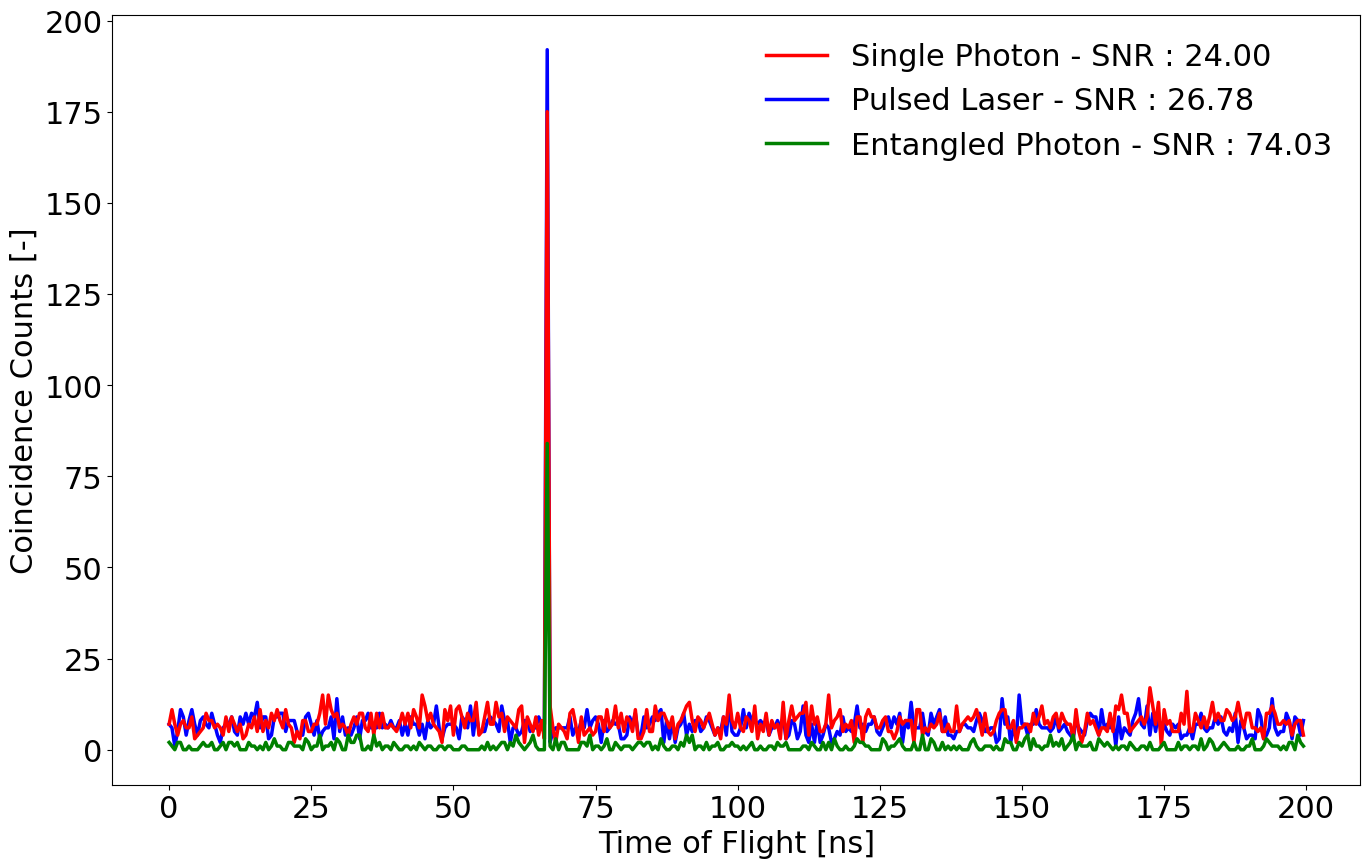

In [22]:
fig = plt.figure(figsize=(16.1, 10))
plt.plot(bin_edges_sps / 1e-9, counts_sps, "-", color="red", label=f"Single Photon - SNR : {snr_sps:.2f}", linewidth=2.5, zorder=2)
plt.plot(bin_edges_pulsed / 1e-9, counts_pulsed, "-", color="blue", label=f"Pulsed Laser - SNR : {snr_pulsed:.2f}", linewidth=2.5, zorder=1)
plt.plot(bin_edges_entangled / 1e-9, counts_entangled, "-", color="green", label=f"Entangled Photon - SNR : {snr_entangled:.2f}", linewidth=2.5, zorder=3)
plt.xlabel('Time of Flight [ns]', fontsize=22)
plt.ylabel('Coincidence Counts [-]', fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.legend(frameon=False, fontsize=22)
plt.show()

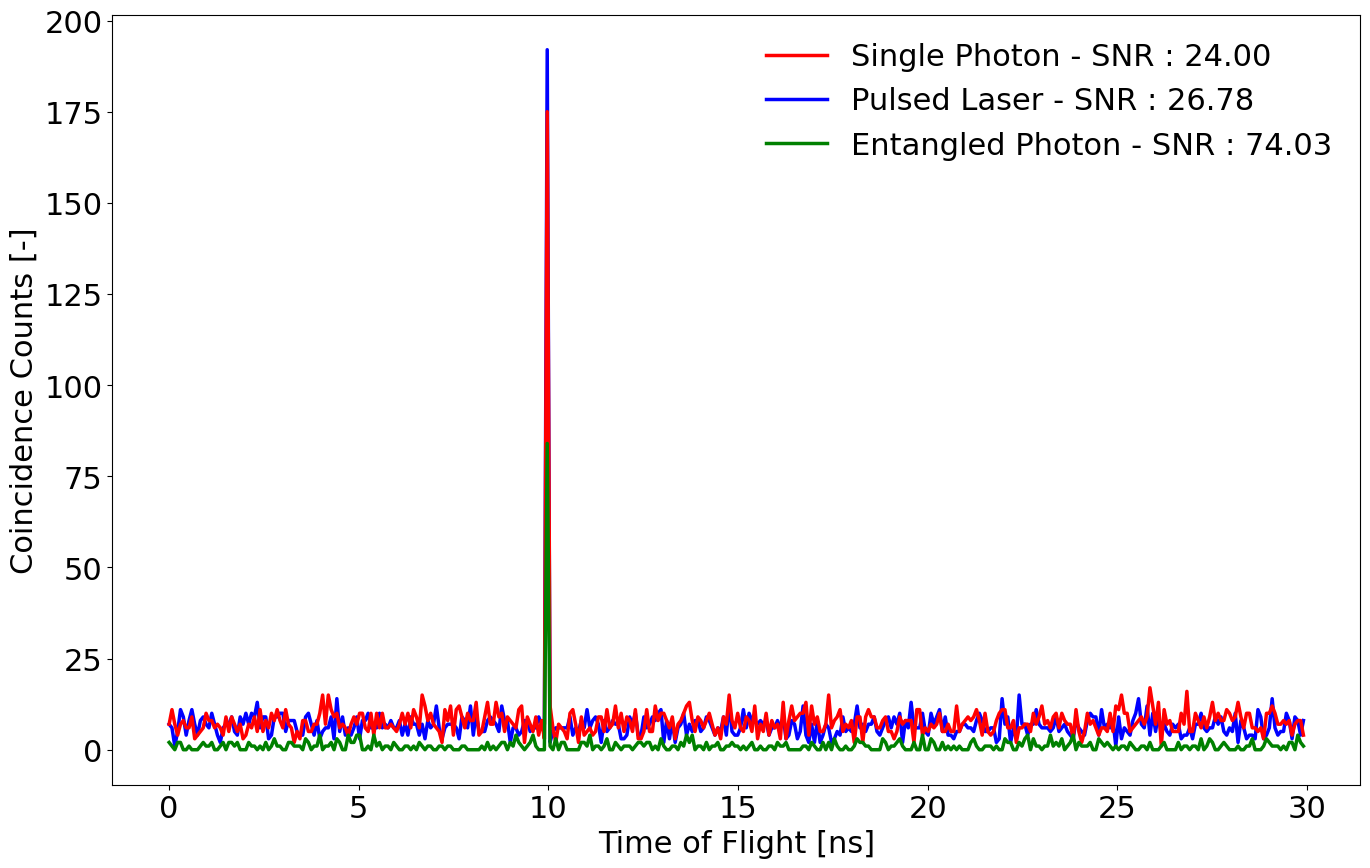

In [21]:
fig = plt.figure(figsize=(16.1, 10))
plt.plot(bin_edges_distance_sps, counts_sps, "-", color="red", label=f"Single Photon - SNR : {snr_sps:.2f}", linewidth=2.5, zorder=2)
plt.plot(bin_edges_distance_pulsed, counts_pulsed, "-", color="blue", label=f"Pulsed Laser - SNR : {snr_pulsed:.2f}", linewidth=2.5, zorder=1)
plt.plot(bin_edges_distance_entangled, counts_entangled, "-", color="green", label=f"Entangled Photon - SNR : {snr_entangled:.2f}", linewidth=2.5, zorder=3)
plt.xlabel('Time of Flight [ns]', fontsize=22)
plt.ylabel('Coincidence Counts [-]', fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.legend(frameon=False, fontsize=22)
plt.show()